# Decision Trees, Over- and Under-fitting, and the Bias-Variance Tradeoff
In this workbook, we will examine **decision trees**, a relatively straighforward technique for classification.   We will use the example dataset and model to introduce the ideas of over and underfitting a model, and the relationship of these ideas to bias and variance.

The data we will use is a public sample of pulsar data.   It includes feature data on approximately 18k human-labeled samples.   A full description of the data and the underlying analysis can be found in this thesis:
https://research.manchester.ac.uk/en/studentTheses/why-are-pulsars-hard-to-find

The data come from the UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/HTRU2

The markdown cell below is copied for convenience from the above UCI link.

## Data Set Information:

HTRU2 is a data set which describes a sample of pulsar candidates collected during the High Time Resolution Universe Survey (South) [1].

Pulsars are a rare type of Neutron star that produce radio emission detectable here on Earth. They are of considerable scientific interest as probes of space-time, the inter-stellar medium, and states of matter (see [2] for more uses).

As pulsars rotate, their emission beam sweeps across the sky, and when this crosses our line of sight, produces a detectable pattern of broadband radio emission. As pulsars
rotate rapidly, this pattern repeats periodically. Thus pulsar search involves looking for periodic radio signals with large radio telescopes.

Each pulsar produces a slightly different emission pattern, which varies slightly with each rotation (see [2] for an introduction to pulsar astrophysics to find out why). Thus a potential signal detection known as a 'candidate', is averaged over many rotations of the pulsar, as determined by the length of an observation. In the absence of additional info, each candidate could potentially describe a real pulsar. However in practice almost all detections are caused by radio frequency interference (RFI) and noise, making legitimate signals hard to find.

Machine learning tools are now being used to automatically label pulsar candidates to facilitate rapid analysis. Classification systems in particular are being widely adopted,
(see [4,5,6,7,8,9]) which treat the candidate data sets as binary classification problems. Here the legitimate pulsar examples are a minority positive class, and spurious examples the majority negative class. At present multi-class labels are unavailable, given the costs associated with data annotation.

The data set shared here contains 16,259 spurious examples caused by RFI/noise, and 1,639 real pulsar examples. These examples have all been checked by human annotators.

The data is presented in two formats: CSV and ARFF (used by the WEKA data mining tool). Candidates are stored in both files in separate rows. Each row lists the variables first, and the class label is the final entry. The class labels used are 0 (negative) and 1 (positive).

Please note that the data contains no positional information or other astronomical details. It is simply feature data extracted from candidate files using the PulsarFeatureLab tool (see [10]).


## Attribute Information:

Each candidate is described by 8 continuous variables, and a single class variable. The first four are simple statistics obtained from the integrated pulse profile (folded profile). This is an array of continuous variables that describe a longitude-resolved version of the signal that has been averaged in both time and frequency (see [3] for more details). The remaining four variables are similarly obtained from the DM-SNR curve (again see [3] for more details). These are summarised below:

1. Mean of the integrated profile.
2. Standard deviation of the integrated profile.
3. Excess kurtosis of the integrated profile.
4. Skewness of the integrated profile.
5. Mean of the DM-SNR curve.
6. Standard deviation of the DM-SNR curve.
7. Excess kurtosis of the DM-SNR curve.
8. Skewness of the DM-SNR curve.
9. Class

HTRU 2 Summary
17,898 total examples.
1,639 positive examples.
16,259 negative examples.

Relevant Papers:

[1] M. J. Keith et al., 'The High Time Resolution Universe Pulsar Survey - I. System Configuration and Initial Discoveries',2010, Monthly Notices of the Royal Astronomical Society, vol. 409, pp. 619-627. DOI: 10.1111/j.1365-2966.2010.17325.x

[2] D. R. Lorimer and M. Kramer, 'Handbook of Pulsar Astronomy', Cambridge University Press, 2005.

[3] R. J. Lyon, 'Why Are Pulsars Hard To Find?', PhD Thesis, University of Manchester, 2016.

[4] R. J. Lyon et al., 'Fifty Years of Pulsar Candidate Selection: From simple filters to a new principled real-time classification approach', Monthly Notices of the Royal Astronomical Society 459 (1), 1104-1123, DOI: 10.1093/mnras/stw656

[5] R. P. Eatough et al., 'Selection of radio pulsar candidates using artificial neural networks', Monthly Notices of the Royal Astronomical Society, vol. 407, no. 4, pp. 2443-2450, 2010.

[6] S. D. Bates et al., 'The high time resolution universe pulsar survey vi. an artificial neural network and timing of 75 pulsars', Monthly Notices of the Royal Astronomical Society, vol. 427, no. 2, pp. 1052-1065, 2012.

[7] D. Thornton, 'The High Time Resolution Radio Sky', PhD thesis, University of Manchester, Jodrell Bank Centre for Astrophysics School of Physics and Astronomy, 2013.

[8] K. J. Lee et al., 'PEACE: pulsar evaluation algorithm for candidate extraction a software package for post-analysis processing of pulsar survey candidates', Monthly Notices of the Royal Astronomical Society, vol. 433, no. 1, pp. 688-694, 2013.

[9] V. Morello et al., 'SPINN: a straightforward machine learning solution to the pulsar candidate selection problem', Monthly Notices of the Royal Astronomical Society, vol. 443, no. 2, pp. 1651-1662, 2014.

[10] R. J. Lyon, 'PulsarFeatureLab', 2015, [Web Link].



# Some important import statements



In [1]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook+pdf'
from sklearn import tree


# Getting the data:
As usual the data is in our project space in /fs/ess/PAS2038/PHYSICS_5680_OSU.   

In [2]:
import pandas as pd
#
# Data lkocation
data_location = '/fs/ess/PAS2038/PHYSICS_5680_OSU/class_data/module4/'
#
# Read in all of the other digits
fname = data_location + 'HTRU_2a.csv'
dfAll = pd.read_csv(fname)
#
# Print the dataframe as a table to see what it looks like
from IPython.display import display
display(dfAll)

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


# Defining Signal
The **class** variable distinguishes signal from background.   As usual,  **1** is signal (pulsars) and **0** is background.

In [3]:
#
# The data already has a 0/1 class variable that defines signal (1) and background (0)
#
# The data is already combined but it will be usefull to split it so we can look at 
# signal and background separately.
#
labels = [1,0]
dfA = dfAll[dfAll['class']==1]
dfB = dfAll[dfAll['class']==0]


print("Length of signal sample:     ",len(dfA))
print("Length of background sample: ",len(dfB))

#
# Shuffle the data here
from sklearn.utils import shuffle
dfBShuffle = shuffle(dfB)
#
# Uncomment the next line to use all of the background
#dfB_use = dfBShuffle

# Uncomment the next line to limit dfB to be the same length as dfA
dfB_use = dfBShuffle.head(len(dfA))

dfCombined = dfB_use
dfCombined = pd.concat([dfCombined, dfA])
dfCombined = shuffle(dfCombined)

print("Size of signal sample ",len(dfA))
print("Size of background sample ",len(dfB_use))
print("Size of combined sample ",len(dfCombined))



Length of signal sample:      1639
Length of background sample:  16259
Size of signal sample  1639
Size of background sample  1639
Size of combined sample  3278


# Examine the Data

Let's do a quick visualization of the correlations - we can look at which variables ar emore strongly correlated with the **class** varaible.

In [4]:
corr = dfCombined.corr()
corr.style.background_gradient()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
Profile_mean,1.000000,0.685172,-0.942729,-0.844197,-0.596092,-0.644757,0.603294,0.436143,-0.776153
Profile_stdev,0.685172,1.000000,-0.722971,-0.735738,-0.232208,-0.352999,0.337325,0.269891,-0.521013
Profile_skewness,-0.942729,-0.722971,1.000000,0.962675,0.609403,0.655719,-0.614239,-0.442599,0.736502
Profile_kurtosis,-0.844197,-0.735738,0.962675,1.000000,0.551914,0.569420,-0.534679,-0.380038,0.608447
DM_mean,-0.596092,-0.232208,0.609403,0.551914,1.000000,0.786353,-0.697788,-0.441068,0.491522
DM_stdev,-0.644757,-0.352999,0.655719,0.569420,0.786353,1.000000,-0.876598,-0.661561,0.678082
DM_skewness,0.603294,0.337325,-0.614239,-0.534679,-0.697788,-0.876598,1.000000,0.916943,-0.635350
DM_kurtosis,0.436143,0.269891,-0.442599,-0.380038,-0.441068,-0.661561,0.916943,1.000000,-0.497325
class,-0.776153,-0.521013,0.736502,0.608447,0.491522,0.678082,-0.635350,-0.497325,1.000000


# Exercise 1
The correlation table above indicates that **Profile_mean** and **Profile_skewness** are among the variables correlated strongly with **class**.  

Make the following 3 plots:
1.  Plot a histogram of Profile_mean, with the color set by **class**.   Use the option 'barmode="overlay"'.
2.  Plot a histogram of Profile_skewness, with the color set by **class**.   Use the option 'barmode="overlay"'.
3.  Plot a scatter plot of Profile_mean vs Profile_skewness, with the color set by **class**. 


In [5]:
# Your code here
color_discrete_map = {1: 'blue', 0: 'red'}
fig = px.histogram(dfCombined, x='Profile_mean', color='class', 
                   barmode="overlay", 
                   color_discrete_map=color_discrete_map,
                   title='Distribution of Profile_mean by Class')
fig.show()

fig = px.histogram(dfCombined, x='Profile_skewness', color='class', 
                   barmode="overlay",
                   color_discrete_map=color_discrete_map,
                   title='Distribution of Profile_skewness by Class')
fig.show()

fig = px.scatter(dfCombined, x='Profile_mean', y='Profile_skewness', 
                 color='class',
                 color_discrete_map=color_discrete_map,
                 title='Profile_mean vs Profile_skewness')
fig.show()


## Exercise 2
Plot histograms as you did above, but this time for the two features with the smallest absolute value correlation with **class**.

In [8]:
print("Correlations with class (sorted by absolute value):")
print(corr['class'].abs().sort_values())

color_discrete_map = {1: 'blue', 0: 'red'}

fig = px.histogram(dfCombined, x='DM_kurtosis', color='class', 
                   barmode="overlay",
                   color_discrete_map=color_discrete_map,
                   title='Distribution of DM_kurtosis by Class')
fig.show()

fig = px.histogram(dfCombined, x='Profile_kurtosis', color='class', 
                   barmode="overlay",
                   color_discrete_map=color_discrete_map,
                   title='Distribution of Profile_kurtosis by Class')
fig.show()

Correlations with class (sorted by absolute value):
DM_mean             0.491522
DM_kurtosis         0.497325
Profile_stdev       0.521013
Profile_kurtosis    0.608447
DM_skewness         0.635350
DM_stdev            0.678082
Profile_skewness    0.736502
Profile_mean        0.776153
class               1.000000
Name: class, dtype: float64


# Performance Method
Define this for later use.

This is a copy of the calc_performance method from the top half (the binary classification part) of inclass_module3.

In [10]:
from sklearn import metrics
from sklearn.metrics import auc
from sklearn import metrics
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from tabulate import tabulate

from sklearn import metrics
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from tabulate import tabulate

def calc_performance(y_vals_true, y_vals_pred, labels,score):
#
# Get the numbers for the confusion matrix
# To get output: cf_matrix[true_label,pred_label]
    cf_matrix = confusion_matrix(y_vals_true, y_vals_pred, labels=labels)
    TP = cf_matrix[0,0]
    FN = cf_matrix[0,1]
    FP = cf_matrix[1,0]
    TN = cf_matrix[1,1]

#
# This is a graphic
    cf_disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix,display_labels=labels)
#
    table = [
        [ "", "Predicted Class 1", "Precicted Class 0"],
        [ "True Class 1", TP, FN ],
        [ "True Class 0", FP, TN ]
    ]
    print_table_type='fancy_grid'
    print_table = tabulate(table, headers='firstrow', tablefmt=print_table_type)
#
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2.0 / ( (1.0/precision) + (1.0/recall) )    
#
# Now get the ROC curve data
    fpr, tpr, threshold = metrics.roc_curve(y_vals_true, score, pos_label=1)
#
# Now get the AUC
    auc_val = auc(fpr,tpr)
#
# Return the matrix as part of a dictionary.   We could have just returned the 
# dictionary itself, but we will be modifying this method and a dictionary makes
# it easy to return mtuliple objects in a organized way
    results = {'confusion_matrix_data':cf_matrix,
                  'confusion_matrix_display':cf_disp,
                  'confusion_matrix_print_table':print_table,
                'precision': precision,
                'recall': recall,
                'f1_score': f1_score,
                'fpr':fpr, 
                'tpr':tpr, 
                'threshold': threshold,
                'auc': auc_val}
    return results


#  The run_fitter Method

First, we copy the run_fitter from the top half (the binary classification part) of inclass_module3.

Next, we need to make a **critical change**.

In module 3, our classifier was the SVC classifier.   To get a ROC curve (which is important for understanding performance) we need to **score** our results.   For SVC, the score comes from its **decision_function** method.   For decision trees in sklearn, we will use the classifier **DecisionClassifier**, and this provides a **predict_proba** function (returning probabilites) instead of the decision_function method.   

Notice that **predict_proba** returns a probability for each class (so 2 in this case), and so we need to select one of those probabilities (the one corresponding to the positive class) for our score. 

If we just do this:
```
y_train_score = estimator.predict_proba(X_train)
```
then we get **two** scores (one for class 0 and one for class 1) for all of our samples.

But if we do this:
```
y_train_score = estimator.predict_proba(X_train)[:,1]
```
then we get **one** score1 (one for class 1)  or all of our samples.



In [11]:

def run_fitter(estimator,df_train_features,df_train_labels,df_test_features,df_test_labels,labels):

    # Actually do the training
    estimator.fit(df_train_features,df_train_labels)
    #
    # Now predict the classes for our train set
    y_train_pred = estimator.predict(df_train_features)
    #
    # Now predict the classes for our test set
    y_test_pred = estimator.predict(df_test_features)
    #
    # Get the results of the decision function for each digit
    y_train_score = estimator.predict_proba(df_train_features)[:,1] 
    y_test_score = estimator.predict_proba(df_test_features)[:,1] 
    #
    # Get resulst for train
    results_train = calc_performance(df_train_labels,y_train_pred,labels,y_train_score)
    #
    # Get resulst for test
    results_test = calc_performance(df_test_labels,y_test_pred,labels,y_test_score)
    #
    return results_train,results_test

# Prepare the data and Run the fitter
Now we can use the function we defined above.   We are going to use the "DecisionTreeClassifier", and initially we will not use k-fold validation.   Let's just see how the decision tree works.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

#
# This is the feature and label data for the full combined sample
dfCombined_features = dfCombined.iloc[:,:8]

# Get the labels
dfCombined_labels = dfCombined['class']
#
# Get our test and train data
df_train_digits,df_test_digits = train_test_split(dfCombined, test_size=0.2, random_state=42)

# Get the features
df_train_features = df_train_digits.iloc[:,:8]

# Get the labels
df_train_labels = df_train_digits['class']

#
# Get the features of the test set
df_test_features = df_test_digits.iloc[:,:8]

#
# Get the labels of the test set
df_test_labels = df_test_digits['class']

#
# Define our estimator.     
estimator = DecisionTreeClassifier(random_state=42)
#
# Call the fitter
labels =[1,0]
results_train,results_test = run_fitter(estimator,df_train_features,df_train_labels,df_test_features,df_test_labels,labels)
#
# Now print out some results

print("Precision train/test ",round(results_train['precision'],3),round(results_test['precision'],3))
print("Recall train/test    ",round(results_train['recall'],3),round(results_test['recall'],3))
print("AUC train/test       ",round(results_train['auc'],3),round(results_test['auc'],3))
print()
print("Confusion matrix for training data:")
print(results_train["confusion_matrix_print_table"])
print()
print("Confusion matrix for test data:")
print(results_test["confusion_matrix_print_table"])

#

Precision train/test  1.0 0.904
Recall train/test     1.0 0.941
AUC train/test        1.0 0.923

Confusion matrix for training data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                1317 │                   0 │
├──────────────┼─────────────────────┼─────────────────────┤
│ True Class 0 │                   0 │                1305 │
╘══════════════╧═════════════════════╧═════════════════════╛

Confusion matrix for test data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                 303 │                  19 │
├──────────────┼─────────────────────┼─────────────────────┤
│ True Class 0 │                  32 │                 302 │
╘══════════════╧═════════════════════╧═══

## Examine Results
Why are the training values all 1.0 and the testing values all around 0.9?   Perfect performance on the training sample is not usually a good thing since it often means you have overfit the data.

It turns out that the decision tree - if not limited - will continue to add nodes until it perfectly separates the training sample into signal and background.   It has **overfit** the training data, and effectively **memorized** the signal and background.  But this comes at the cost of **generalization**.    The trained model finds it difficult to generalize its procedure to new unseen testing data.   To fix this, we need to limit the decision tree so that it is less likely to overfit.   

If we look at sklearn in detail at how the DecisionTreeClassifier can be called, we will see the parameters that we can play with:

    class sklearn.tree.DecisionTreeClassifier(criterion=’gini’, splitter=’best’, max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, class_weight=None, presort=False)

Here are the descriptions of some of the key parameters:
*  **max_depth : int or None, optional (default=None)**
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

*  **min_samples_split : int, float, optional (default=2)**
The minimum number of samples required to split an internal node:
If int, then consider min_samples_split as the minimum number.
If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

*  **min_samples_leaf : int, float, optional (default=1)**
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
If int, then consider min_samples_leaf as the minimum number.
If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.

* **max_leaf_nodes : int or None, optional (default=None)**
Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.

To help us understand the decision tree we ended up with, it turns out we have access to a nice visualization tool (the **tree** method from **sklearn**, included in the methods at the top of this workbook).   Lets call it and see what the (overtrained) tree looks like when it is trained using all of the default parameters:

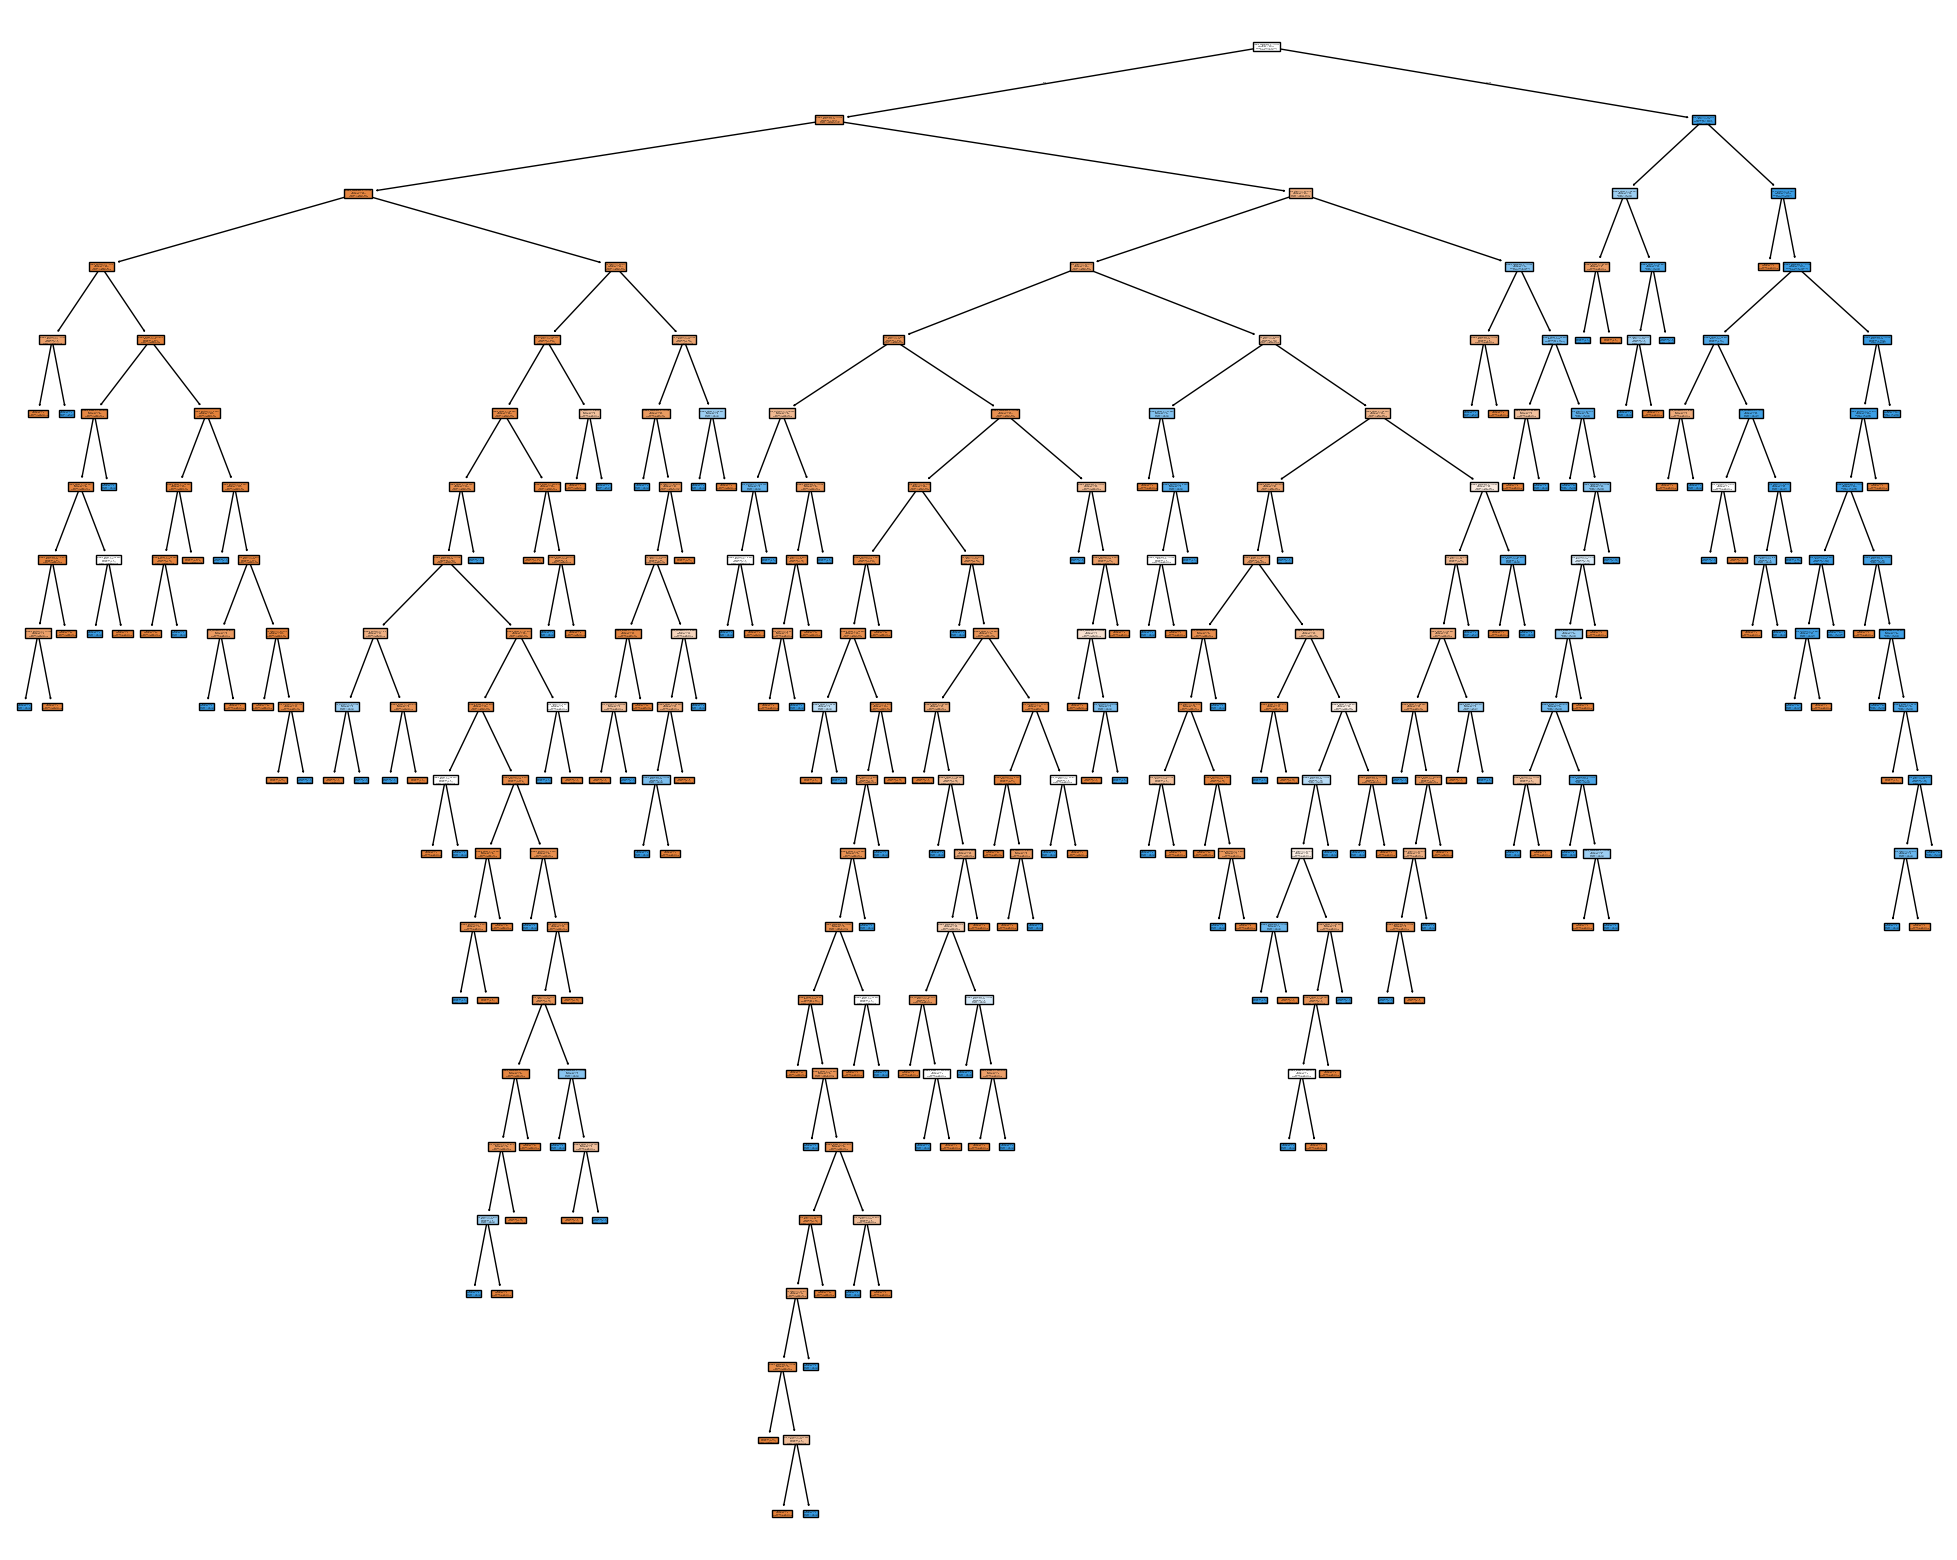

In [13]:
from matplotlib import pyplot as plt
from sklearn import tree
from IPython.display import SVG
class_names = {0:"background",1:"signal"}
class_names = ["background","signal"]
classColumn='class'
feature_names = [col for col in dfCombined.columns if col!=classColumn]
#
# Use a method from sklearn to visualize the tree
fig = plt.figure(figsize=(25,20))
tree.plot_tree(estimator,feature_names=feature_names,class_names=class_names,filled=True)
plt.show()


## Making a simpler Decision Tree
The default tree ended up with more than 200 **interior nodes** and **leaves**, which makes it quite difficult to understand.   (Aside: why is it so complicated?   By default, an unconstrained tree will **grow** until every final **leaf** is pure.   More on that later.)   Let's try limiting that by requiring the number of leaves (**which are nodes with no children**) to something more manageable: we will set max_leaf_nodes=5.   We will define the estimator with this parameter, run the algorithm, and then display the resultant decision tree.

NOTE: Count the leaves with no children to make sure you see how to get 5!

Precision train/test  0.969 0.968
Recall train/test     0.909 0.935
AUC train/test        0.966 0.976

Confusion matrix for training data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                1197 │                 120 │
├──────────────┼─────────────────────┼─────────────────────┤
│ True Class 0 │                  38 │                1267 │
╘══════════════╧═════════════════════╧═════════════════════╛

Confusion matrix for test data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                 301 │                  21 │
├──────────────┼─────────────────────┼─────────────────────┤
│ True Class 0 │                  10 │                 324 │
╘══════════════╧═══════════════════

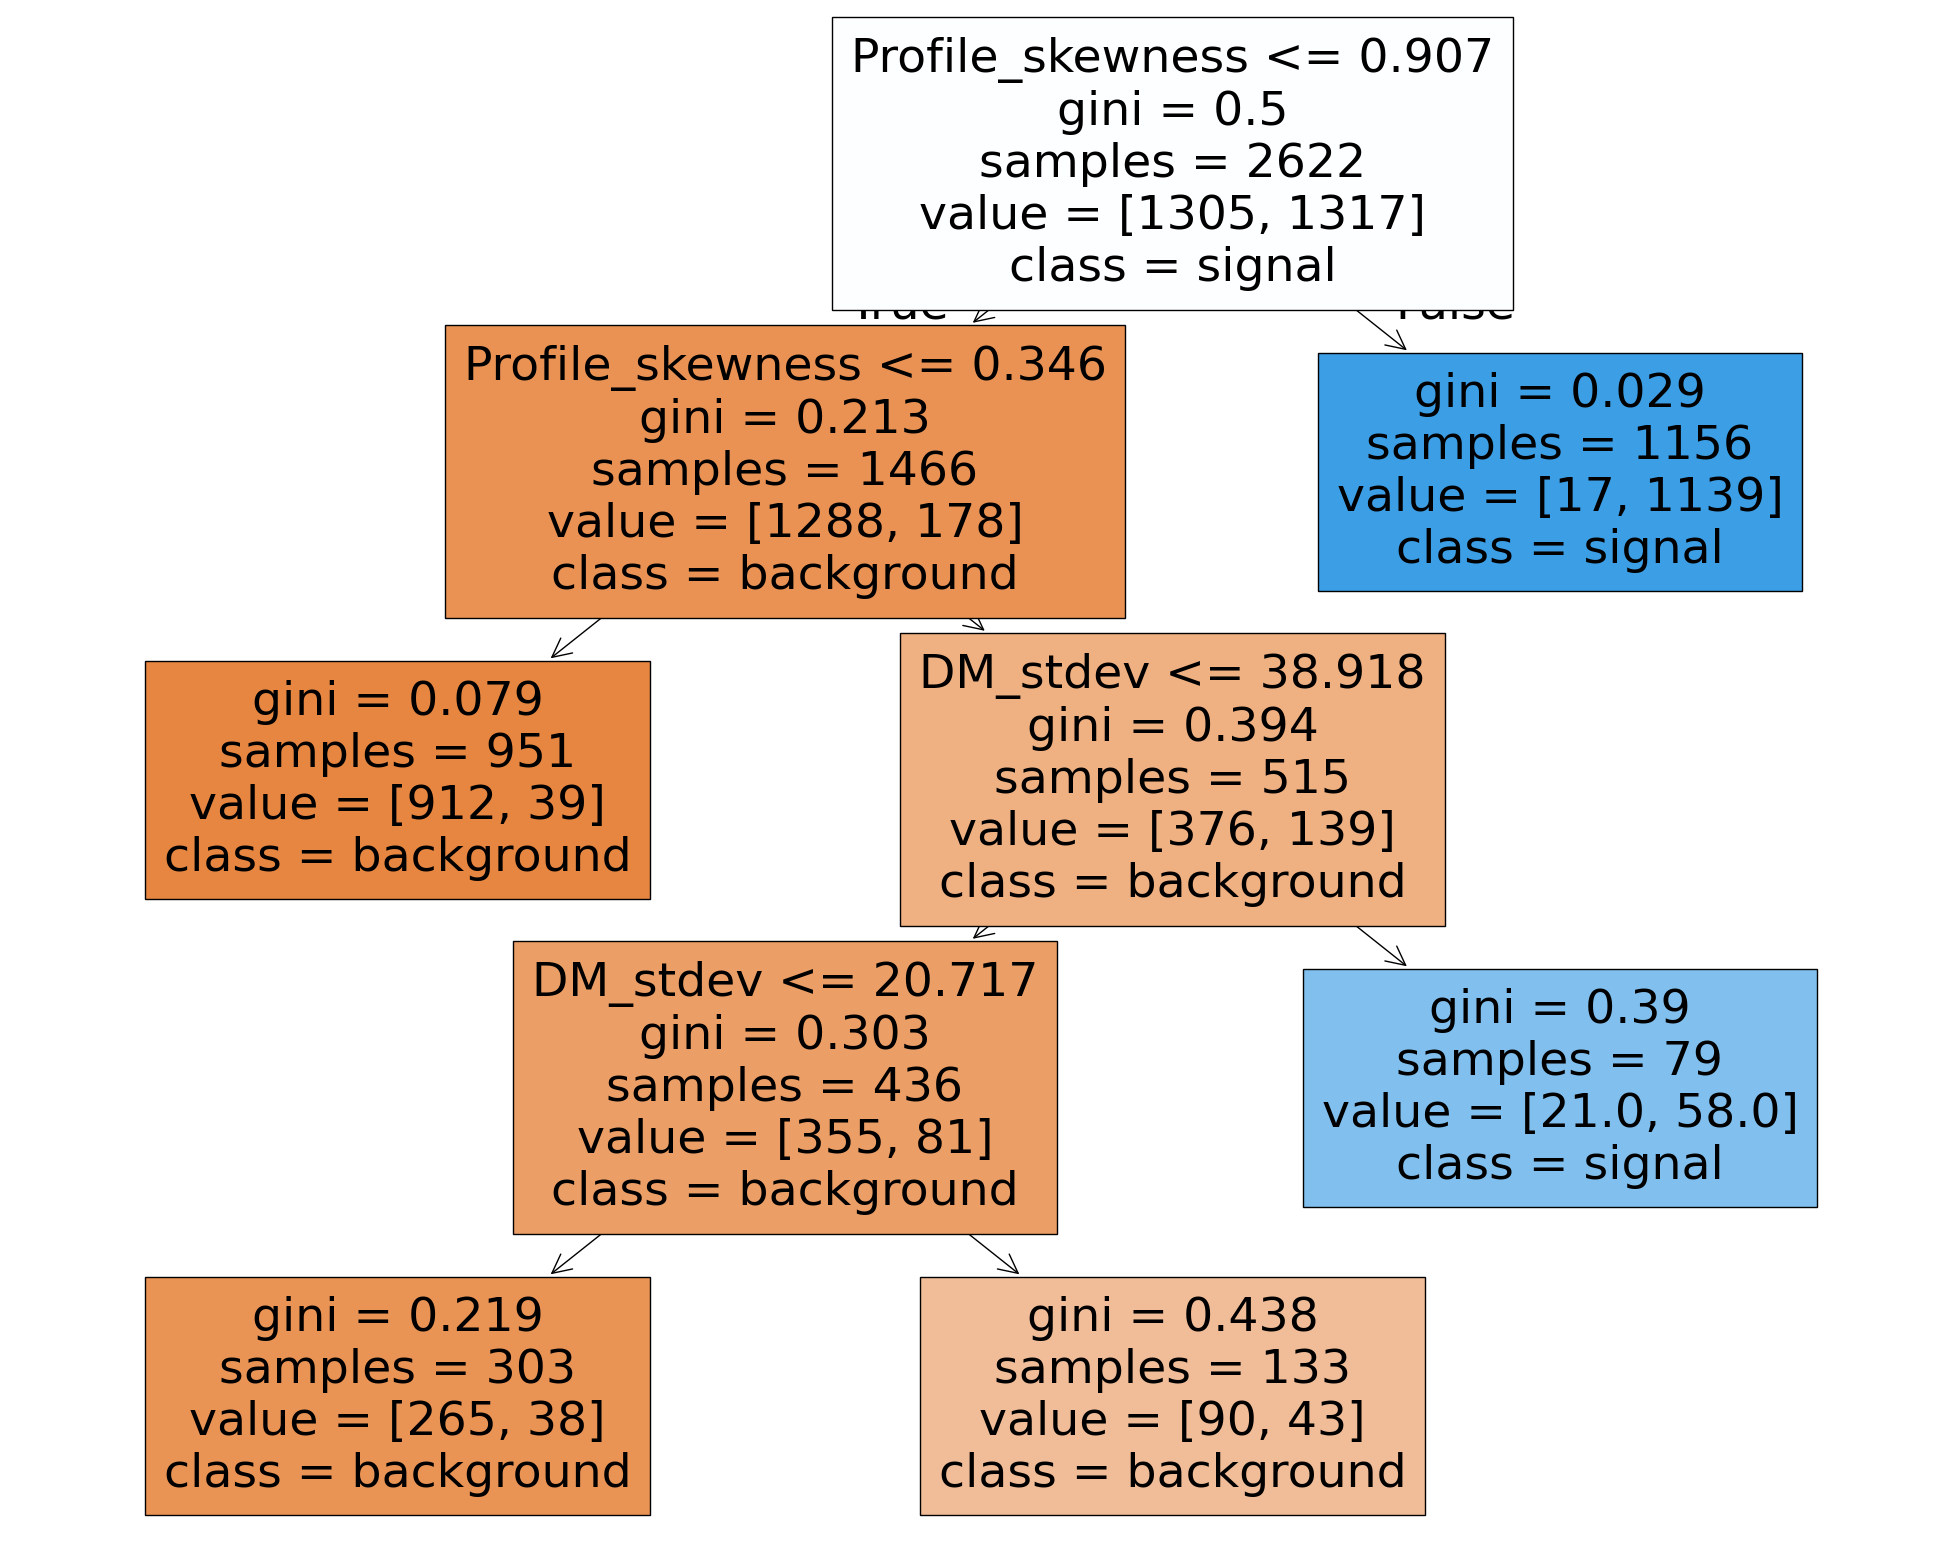

In [14]:
#
# Modify the parameters of the tree we will train
estimator = DecisionTreeClassifier(random_state=42,max_leaf_nodes=5)
#
# Fit the tree
labels =[1,0]
results_train,results_test = run_fitter(estimator,df_train_features,df_train_labels,df_test_features,df_test_labels,labels)
#
print("Precision train/test ",round(results_train['precision'],3),round(results_test['precision'],3))
print("Recall train/test    ",round(results_train['recall'],3),round(results_test['recall'],3))
print("AUC train/test       ",round(results_train['auc'],3),round(results_test['auc'],3))
print()
print("Confusion matrix for training data:")
print(results_train["confusion_matrix_print_table"])
print()
print("Confusion matrix for test data:")
print(results_test["confusion_matrix_print_table"])
#
# Plot the tree!
fig = plt.figure(figsize=(25,20))
tree.plot_tree(estimator,feature_names=feature_names,class_names=class_names,filled=True)
plt.show()

## Exercise 3:   Another simple (but different!) Decision Tree
That one above looks much simpler!    Before going into detail on what the various parts mean, let's try another parameter: the number of levels in the tree.    We adjust this using **max_depth**.   Note that the number of "leaf nodes" is now free to be anything.

Try this twice: 
- Once with max_depth=1
- Once with max_depth=2

Keep track of:
- the total number of nodes (including the root node)
- the AUC for both test and train

You will need these numbers for the table below.

In [19]:
from sklearn.metrics import roc_auc_score
X = dfAll.drop('class', axis=1)
y = dfAll['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

results = [] 

tree_depth1 = DecisionTreeClassifier(max_depth=1, random_state=0)
tree_depth1.fit(X_train, y_train)

y_train_pred1 = tree_depth1.predict_proba(X_train)[:,1]
y_test_pred1  = tree_depth1.predict_proba(X_test)[:,1]

auc_train1 = roc_auc_score(y_train, y_train_pred1)
auc_test1  = roc_auc_score(y_test, y_test_pred1)

print("Max Depth = 1")
print("Number of nodes:", tree_depth1.tree_.node_count)
print("AUC Train:", auc_train1)
print("AUC Test:", auc_test1)

results.append([tree_depth1.tree_.node_count, auc_train1, auc_test1])

tree_depth2 = DecisionTreeClassifier(max_depth=2, random_state=0)
tree_depth2.fit(X_train, y_train)

y_train_pred2 = tree_depth2.predict_proba(X_train)[:,1]
y_test_pred2  = tree_depth2.predict_proba(X_test)[:,1]

auc_train2 = roc_auc_score(y_train, y_train_pred2)
auc_test2  = roc_auc_score(y_test, y_test_pred2)

print("\nMax Depth = 2")
print("Number of nodes:", tree_depth2.tree_.node_count)
print("AUC Train:", auc_train2)
print("AUC Test:", auc_test2)

results.append([tree_depth2.tree_.node_count, auc_train2, auc_test2])

Max Depth = 1
Number of nodes: 3
AUC Train: 0.9087260535806445
AUC Test: 0.9147748751181315

Max Depth = 2
Number of nodes: 7
AUC Train: 0.9314999392229395
AUC Test: 0.930080329418118


In [20]:
tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_depth3.fit(X_train, y_train)

y_train_pred3 = tree_depth3.predict_proba(X_train)[:,1]
y_test_pred3  = tree_depth3.predict_proba(X_test)[:,1]

auc_train3 = roc_auc_score(y_train, y_train_pred3)
auc_test3  = roc_auc_score(y_test, y_test_pred3)

print("Max Depth = 3")
print("Number of nodes:", tree_depth3.tree_.node_count)
print("AUC Train:", auc_train3)
print("AUC Test:", auc_test3)


Max Depth = 3
Number of nodes: 15
AUC Train: 0.9636086405407717
AUC Test: 0.9659200756041584


# Exercise 4
Make a nice table with the following three columns:
- Number of nodes
- AUC Train
- AUC Test

Fill this table (*use tabulate, but you can just fill the contents by hand (i.e. not programmatically) with the following rows:
- Results from the max_leaf_nodes=5 tree
- Results from the depth=3 tree
- Results from the unconstrained tree (assume the number of nodes is 200)

Look what happens to Train and Test AUC as the number of nodes goes from small (less complex) to large (more complex).

In [21]:
# your code here
from tabulate import tabulate
print_table_type='fancy_grid'
print()
print('These are the tree results versus number of nodes.')
table = [
    [ "Number of Nodes", "AUC Train", "AUC Test"],
    [ "Max Depth = 1", 3, 0.9087, 0.9148],
    ["Max Depth = 2", 7, 0.9315, 0.9301],
    ["Max Depth = 3", 15, 0.9636, 0.9659],
    ["Max Leaf Nodes = 5", "(5 leaf nodes)", 0.966, 0.976],
    ["Unconstrained", 200, 1.0, 0.923],
]
print_table = tabulate(table, headers='firstrow', tablefmt=print_table_type)
print(print_table)
#print_table(table)


These are the tree results versus number of nodes.
╒════════════════════╤═══════════════════╤═════════════╤════════════╕
│                    │ Number of Nodes   │   AUC Train │   AUC Test │
╞════════════════════╪═══════════════════╪═════════════╪════════════╡
│ Max Depth = 1      │ 3                 │      0.9087 │     0.9148 │
├────────────────────┼───────────────────┼─────────────┼────────────┤
│ Max Depth = 2      │ 7                 │      0.9315 │     0.9301 │
├────────────────────┼───────────────────┼─────────────┼────────────┤
│ Max Depth = 3      │ 15                │      0.9636 │     0.9659 │
├────────────────────┼───────────────────┼─────────────┼────────────┤
│ Max Leaf Nodes = 5 │ (5 leaf nodes)    │      0.966  │     0.976  │
├────────────────────┼───────────────────┼─────────────┼────────────┤
│ Unconstrained      │ 200               │      1      │     0.923  │
╘════════════════════╧═══════════════════╧═════════════╧════════════╛


## Examination of the tree
Let's look at this last tree in detail.   
**NOTE**: since there may be slight variances in the random number generators used in my workbook and yours, the numbers above in the tree may be slightly different.  In fact, there may be differences depending on the version of python used (the above tree used python 3.9, while the figure below used python 3.6). 

Here is a screenshot of the tree corresponding to the numbers used below:
https://github.com/big-data-analytics-physics/data/blob/master/images/simleTree2.png

![my tree](images/small_decision_tree.png)

There are a few things to point out:
1.  The is one root node - node #0 at the very top of the tree.   Looking at the text in this node:
    * node #0: This is the node name.
    * Cut: Profile_skewness ≤ 0.889.    This the cut that the children of this node either pass and go to the left (labeled "True") or fail and go to the right (labeled "False").   
     * gini = 0.5:   This is the **gini impurity** of the root node.   We will cover this below, but note that for a balanced dataset with equal or nearly equal signal and background, gini=0.5 for the root node. (**NOTE**: gini **coefficient** is a different idea.  It is also sometimes called the gini index, or the gini ratio, and is a measure of statistical dispersion.  Also note that, unfortunately, some writeups of Decision Trees confuse these terms.)
     * samples = 2622: This is the number of samples in *this* node.
     * value = [1288, 1334]:  This is the **actual** number of background (1288) and signal (1334) the node has.   Note the this is **different** than the number that go to the left (1431) and the right (1191), which you find by looking at the **samples** number of the children of this node.
     * class = background: This is the class characterization of the node.   Since there are slighty more background than signal, this node is counted as background.   Note that the nodes get more orange the more background the node has, and more blue the more signal the node has.
2.   There are 8 **leaves** in this tree.   A leaf is a node with no children.   It turns out that for this tree, all of the leaves are on the bottom level, but  this is not usually the case (look at the previous 2 trees to see this).
3.  Looking at the left-most leaf on the bottom level we see two imortant things:
     * value = [593, 9]  This means that if a new data sample as passed through this decision tree, and it landed on this node, it would have a probability of p_0=593/602 of being background, and a probability of p_1 =9/602 of being signal.
     * gini=0.029:   A much lower **gini impurity**.   What is gini impurity?

<img src="images/gini_index_eq.png" width="200"/>

where in our case J=2 (because we have two classes).   Substituting p_0=593/602 and p_1=9/602 yields G=0.029.
The **gini impurity**  of a node is the probability that a randomly chosen sample in a node would be incorrectly labeled, if it was labeled by the distribution of samples in the node. 

This gives us some insight into how a decision tree is formed:   At each node, the algorithm loops over all of the features *k* and all possible splits (or thresholds) t_k among those features, to determine a split (or cut point) that results in the purest children of that node.   Mathematically, it finds the pair (k,t_k) that minimizes the following cost function:


<img src="images/j_equation.png" width="300"/>

where *left* and *right* refer the the child on the left or right.

     

# Now include k-fold cross validation
Let's retrain the same tree (the second *simple* version), but now include cross validation.

In [22]:
from sklearn.model_selection import StratifiedKFold
kfolds = 5
skf = StratifiedKFold(n_splits=kfolds)

In [23]:
#
# Get our estimator and predict
from sklearn.tree import DecisionTreeClassifier

estimator = DecisionTreeClassifier(random_state=42,max_depth=3)
avg_precision_train = 0.0
avg_recall_train = 0.0
avg_auc_train = 0.0
avg_precision_test = 0.0
avg_recall_test = 0.0
avg_auc_test = 0.0
numSplits = 0.0
#
# Now loop
numSplits = 0
for train_index, test_index in skf.split(dfCombined_features,dfCombined_labels):
    print("Training; loop counter",numSplits)
    numSplits += 1
    df_train_features = dfCombined_features.iloc[train_index]
    df_train_labels = dfCombined_labels.iloc[train_index]
    df_test_features = dfCombined_features.iloc[test_index]
    df_test_labels = dfCombined_labels.iloc[test_index]  
#
# Now fit to our training set
    labels =[1,0]
    results_train,results_test = run_fitter(estimator,df_train_features,df_train_labels,df_test_features,df_test_labels,labels)


    avg_precision_train += results_train['precision']
    avg_recall_train += results_train['recall']
    avg_auc_train += results_train['auc']
#
    avg_precision_test += results_test['precision']
    avg_recall_test += results_test['recall']
    avg_auc_test += results_test['auc']
#
avg_precision_train /= numSplits
avg_recall_train /= numSplits
avg_auc_train /= numSplits
avg_precision_test /= numSplits
avg_recall_test /= numSplits
avg_auc_test /= numSplits
# 
# Now print
print("Precision train/test ",round(avg_precision_train,3),round(avg_precision_test,3))
print("Recall train/test    ",round(avg_recall_train,3),round(avg_recall_test,3))
print("AUC train/test       ",round(avg_auc_train,3),round(avg_auc_test,3))
print()
print("The LAST kfold Confusion matrix for training data:")
print(results_train["confusion_matrix_print_table"])
print()
print("The LAST kfold Confusion matrix for test data:")
print(results_test["confusion_matrix_print_table"])

Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
Precision train/test  0.967 0.955
Recall train/test     0.921 0.915
AUC train/test        0.974 0.969

The LAST kfold Confusion matrix for training data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                1205 │                 106 │
├──────────────┼─────────────────────┼─────────────────────┤
│ True Class 0 │                  40 │                1272 │
╘══════════════╧═════════════════════╧═════════════════════╛

The LAST kfold Confusion matrix for test data:
╒══════════════╤═════════════════════╤═════════════════════╕
│              │   Predicted Class 1 │   Precicted Class 0 │
╞══════════════╪═════════════════════╪═════════════════════╡
│ True Class 1 │                 301 │                  27 │
├─

# Overfitting vs Underfitting
We have seen a very compex tree (allowing the tree to **fully grow** until all leaves are pure) as well as a number of very simple trees.  Of course, we have many possible choices for the various hyperparameters, which will lead to a variety of different expected performance measures.   How do we choose among all of the possibilities?

Let's modify the above k-fold validation, putting it inside of a loop that varies the hyperparameters.   We will store the resultant performance measures, and then plot them versus our hyperparameters.   

For our test, we will vary just one hyperparemter (the tree max_depth) but we could easily do this over multiple hyperparameters.

**NOTE**: we will make one change.   Rather than storing precision, recall, and AUC, which in some sense reflect **accuracy** of our models, we will instead store 1-precision, 1-recall, and 1-AUC, which will reflect **error** in our models.

**ALSO NOTE** we store our results for each run of max_depth in a dictionary, and append that dictionary to a list.   After our loop is done, we can then turn our list of dictionaries into a dataframe with just one line!   We can then easily plot out of that dataframe!

In [24]:
#
# Get our estimator and predict
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
#
# Create a list to store our results
rows = []
#
# OUTER loop over hyperparameters
for max_depth in range(1,20):
    print("training with max depth =",max_depth)
#
# See how we change the estimator by modifying its max_depth!!
    estimator = DecisionTreeClassifier(random_state=42,max_depth=max_depth)
#
# INNER loop over k-fold splits
    avg_precision_train = 0.0
    avg_recall_train = 0.0
    avg_auc_train = 0.0
    avg_precision_test = 0.0
    avg_recall_test = 0.0
    avg_auc_test = 0.0
#
# Now loop
    numSplits = 0
    for train_index, test_index in skf.split(dfCombined_features,dfCombined_labels):
        print("Training; loop counter",numSplits)
        numSplits += 1
        df_train_features = dfCombined_features.iloc[train_index]
        df_train_labels = dfCombined_labels.iloc[train_index]
        df_test_features = dfCombined_features.iloc[test_index]
        df_test_labels = dfCombined_labels.iloc[test_index]  
#
# Now fit to our training set
        labels =[1,0]
        results_train,results_test = run_fitter(estimator,df_train_features,df_train_labels,df_test_features,df_test_labels,labels)
#
        avg_precision_train += results_train['precision']
        avg_recall_train += results_train['recall']
        avg_auc_train += results_train['auc']
#
        avg_precision_test += results_test['precision']
        avg_recall_test += results_test['recall']
        avg_auc_test += results_test['auc']
#
# Store the results for each HYPERPARAMETER iteration
    avg_precision_train /= numSplits
    avg_recall_train /= numSplits
    avg_auc_train /= numSplits
    avg_precision_test /= numSplits
    avg_recall_test /= numSplits
    avg_auc_test /= numSplits
#
# Store the results for this run in a dictionary, and append that dictionary to a list
    rows.append({
         'max_depth':max_depth,
         'trainError_pre':1.0-avg_precision_train,'testError_pre':1.0-avg_precision_test,
         'trainError_rec':1.0-avg_recall_train,'testError_rec':1.0-avg_recall_test,
         'trainError_auc':1.0-avg_auc_train,'testError_auc':1.0-avg_auc_test
          })
#
# Convert our list of dictionaries to a dataframe
dfError = pd.DataFrame(rows)
# 
# Now print
print(dfError.head(10))

training with max depth = 1
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 2
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 3
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 4
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 5
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 6
Training; loop counter 0
Training; loop counter 1
Training; loop counter 2
Training; loop counter 3
Training; loop counter 4
training with max depth = 7
Training; loop counter 0
Training; loop counter 1
Trai

# Plotting results

Lets look at the error measures:
1.  train/test Error using precision: remember that **precision** = TP/(TP+FP) = "Total actual positive found as positive" / "Total our model identified as positive".   It is the fraction of identified postives that are truly positive.   **(1-precision)** is then the **error** - the fraction of our identified postives that are incorrect.
2.  train/test Error using recall: remember that **recall** = TP/(TP+FN) = "Total actual positive found as positive" / "Total actual positive".   It is the fraction of actual positives that our model managed to identify.   **(1-recall)** is then the **error** - the fraction of actual postives that we failed to identify.
3.  train/test Error using AUC: remember that AUC measures the probability that a randomly chosen positive example is properly ranked above a randomly chosen negative example.   **(1-AUC)** is then the probability that we will fail to do this.

In [ ]:
fig = px.line(dfError,x='max_depth', y=['trainError_pre','testError_pre'],
                      title='Error (Precision) vs Model Complexity')
fig.show()

fig = px.line(dfError,x='max_depth', y=['trainError_rec','testError_rec'],
                      title='Error (Recall) vs Model Complexity')
fig.show()

fig = px.line(dfError,x='max_depth', y=['trainError_auc','testError_auc'],
                      title='Error (AUC) vs Model Complexity')
fig.show()





# Defining Underfitting and Overfitting Regions
Looking at the AUC error vs max_depth curve we can see some general trends:
1.   Note that as max_depth increases from left to right, we allow the model to get progressively more complex.
2.   At the far left, as we go from very low complexity to slightly higher complexity, both the training error and the testing error go down.   This is typical.   Also note that the testing error is usually a bit above the trainining error in this region - also fairly typical.   In this region, the model is **underfit** - it still has room to improve on the testing set.
      * Underfit models tend to have the similar fit performance on a testing set as they do on a training set.
3.   As the complexity increases, around max_depth of 3 or 4 or so, the training error decreases, and so does the testing error, but the testing error begins to level out.   What is happening here is that our trained model is becoming more sensitive to features found only in the training set, and so the perfromance on the testing set improves less.
4.  Beyond max_depth of 5-6, the model performance continue to improve on the training set, and begins to get **worse** on the testing set.   The model is now **overfit** - it is memorizing the training set, at the expense of learning general features which would allow it to improve on the testing set.
      * Overfit models tend to have  worser fit performance on a testing set than they do on a training set.



In [25]:
import plotly.graph_objects as go


fig = px.line(dfError,x='max_depth', y=['trainError_auc','testError_auc'],
                      title='Error (AUC) vs Model Complexity')
fig.update_layout(shapes=[
    dict(
        opacity= 0.2,
        xref= "x",
        yref= "y",
        fillcolor= "#d3d3d3",
        y1= 0.09,
        y0= 0.0,
        x0= 1,
        x1= 3,
        type= "rect"
    ),
    dict(
        opacity= 0.2,
        xref= "x",
        yref= "y",
        fillcolor= "#d3d3d3",
        y1= 0.09,
        y0= 0.0,
        x0= 5,
        x1= 20,
        type= "rect"
    )
    ],
    annotations= [
      {
        "xref": "x",
        "yref": "y",
        "text": "Underfit Model",
        "y": 0.095,
        "x": 2.0,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 18
        },
        "showarrow": False
      },
      {
        "xref": "x",
        "yref": "y",
        "text": "High Bias",
        "y": 0.085,
        "x": 2.0,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 15
        },
        "showarrow": False
      },
      {
        "xref": "x",
        "yref": "y",
        "text": "Low Variance",
        "y": 0.075,
        "x": 2.3,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 15
        },
        "showarrow": False
      },
          {
        "xref": "x",
        "yref": "y",
        "text": "Progressively more Overfit Model",
        "y": 0.095,
        "x": 12.5,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 18
        },
        "showarrow": False
      },
      {
        "xref": "x",
        "yref": "y",
        "text": "Low Bias",
        "y": 0.085,
        "x": 10.5,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 15
        },
        "showarrow": False
      },
      {
        "xref": "x",
        "yref": "y",
        "text": "High Variance",
        "y": 0.075,
        "x": 10.8,
        "font": {
          "color": "rgb(255, 0, 0)",
          "size": 15
        },
        "showarrow": False
      },

]
)
fig.show()


# The Bias-Variance Tradeoff
The issue of over and under fitting in our models is strongly related to the concepts of bias and variance.   Within the context of classification:
1.  **Bias** refers to the systematic difference between the average of our predictions and the average of the true labels in our dataset.
     *  Bias decreases with increasing complexity of our model
     *  Bias generally does not depend on training set size.
     *  We want **low bias**.  If the bias is large, **both** training and testing error will be large, and the model is **underfit**.
2. **Variance** refers to the difference between the predictions and our labels for different realizations of the same model.
     * Variance increases with increasing complexity of our model.
     * Variance decreases with training set size.
     * We want **low variance**.   If the variance is large, the testing error will be significantly larger than the training error, and the model is **overfit**.
     
An excellent discussion of these points can be found in this [reference](http://scott.fortmann-roe.com/docs/BiasVariance.html).   The key idea is that although we want both **low bias** and **low variance**, we have only one knob to turn: the complexity of our model.   As we increase the complexity, we can get bias to go down, but eventually, variance will go up.   

In practice this is handled by making the above error plot: we compare the error on the **testing** set to the error on the **training** set.   We expect these both to decrease up to some point, beyond which the testing error increases, while the training error continues to decrease.   We choose our model operating point (the hyperparameters) which correspond to the minimum of our testing error.


# Exercise 5: Optimize decision tree using number of leaves instead of depth
Follow the same strategy as above, leaving the max_depth unspecified, but instead varying the max_leaf_nodes from 2 to 20.   Examine the Error vs max_leave_nodes to determine the ideal setting for this hyperparameter.

As you go through the loop, keep track of the max_leaf_nodes which yields maximum average AUC for the test sample (or minimum AUC error).   Cal this max_leaf_nodes best_max_leaf_nodes.   When the loop is done, print out the maximum AUC as well as the corresponding max_leaf_nodes.

Plot the error for AUC< Recall, and Precision, all vs max_leaf_nodes, as we have above.

In [29]:
 from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

X = dfAll.drop("class", axis=1)
y = dfAll["class"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = DecisionTreeClassifier(max_leaf_nodes=5, random_state=0)
    clf.fit(X_train, y_train)
    y_test_prob = clf.predict_proba(X_test)[:,1]

    print("Fold AUC:", roc_auc_score(y_test, y_test_prob))


Fold AUC: 0.9243139306393064
Fold AUC: 0.9283213144631447
Fold AUC: 0.9456947694476945
Fold AUC: 0.9254605963490826
Fold AUC: 0.9393001027826335


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
from sklearn.model_selection import StratifiedKFold

X = dfAll.drop("class", axis=1)
y = dfAll["class"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

rows = []
best_max_leaf_nodes = 0
best_auc_avg = 0.0

for max_leaf_nodes in range(2, 20):
    print("training with max leaf nodes =", max_leaf_nodes)
    estimator = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=0)

    precision_train = recall_train = auc_train = f1_train = 0.0
    precision_test = recall_test = auc_test = f1_test = 0.0
    numSplits = 0

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        estimator.fit(X_train, y_train)

        y_train_pred = estimator.predict(X_train)
        y_test_pred  = estimator.predict(X_test)

        y_train_prob = estimator.predict_proba(X_train)[:,1]
        y_test_prob  = estimator.predict_proba(X_test)[:,1]

        precision_train += precision_score(y_train, y_train_pred)
        recall_train    += recall_score(y_train, y_train_pred)
        auc_train       += roc_auc_score(y_train, y_train_prob)
        f1_train        += f1_score(y_train, y_train_pred)

        precision_test  += precision_score(y_test, y_test_pred)
        recall_test     += recall_score(y_test, y_test_pred)
        auc_test        += roc_auc_score(y_test, y_test_prob)
        f1_test         += f1_score(y_test, y_test_pred)

        numSplits += 1

    # average across folds
    precision_train /= numSplits
    recall_train    /= numSplits
    auc_train       /= numSplits
    f1_train        /= numSplits

    precision_test  /= numSplits
    recall_test     /= numSplits
    auc_test        /= numSplits
    f1_test         /= numSplits
    
    if auc_test > best_auc_avg:
        best_auc_avg = auc_test
        best_max_leaf_nodes = max_leaf_nodes

    rows.append({
        'max_leaf_nodes': max_leaf_nodes,
        'trainError_pre': 1.0 - precision_train, 'testError_pre': 1.0 - precision_test,
        'trainError_rec': 1.0 - recall_train,    'testError_rec': 1.0 - recall_test,
        'trainError_auc': 1.0 - auc_train,       'testError_auc': 1.0 - auc_test,
        'trainError_f1':  1.0 - f1_train,        'testError_f1': 1.0 - f1_test
    })

dfError = pd.DataFrame(rows)

print("Best AUC:", best_auc_avg)
print("Best max_leaf_nodes:", best_max_leaf_nodes)

training with max leaf nodes = 2
training with max leaf nodes = 3
training with max leaf nodes = 4
training with max leaf nodes = 5
training with max leaf nodes = 6
training with max leaf nodes = 7
training with max leaf nodes = 8
training with max leaf nodes = 9
training with max leaf nodes = 10
training with max leaf nodes = 11
training with max leaf nodes = 12
training with max leaf nodes = 13
training with max leaf nodes = 14
training with max leaf nodes = 15
training with max leaf nodes = 16
training with max leaf nodes = 17
training with max leaf nodes = 18
training with max leaf nodes = 19
Best AUC: 0.9639752057383699
Best max_leaf_nodes: 15


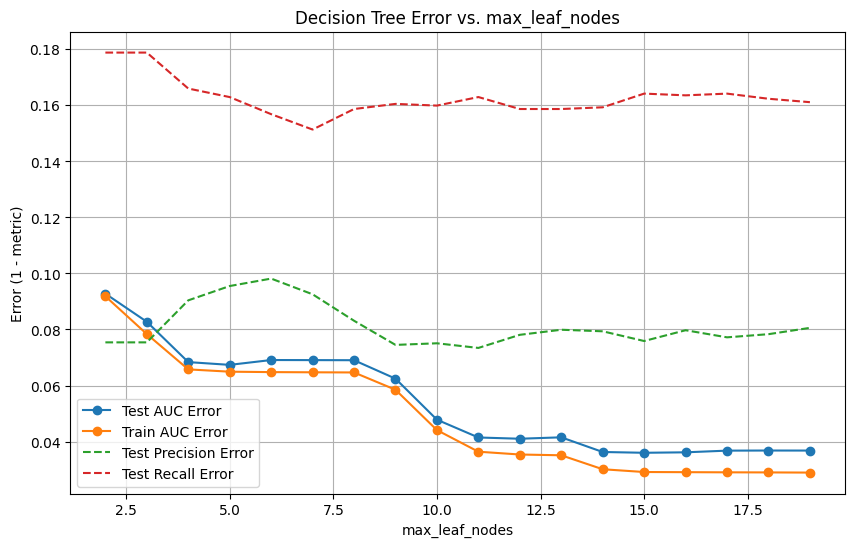

In [36]:
# Now plot!
plt.figure(figsize=(10,6))
plt.plot(dfError["max_leaf_nodes"], dfError["testError_auc"], label="Test AUC Error", marker="o")
plt.plot(dfError["max_leaf_nodes"], dfError["trainError_auc"], label="Train AUC Error", marker="o")
plt.plot(dfError["max_leaf_nodes"], dfError["testError_pre"], label="Test Precision Error", linestyle="--")
plt.plot(dfError["max_leaf_nodes"], dfError["testError_rec"], label="Test Recall Error", linestyle="--")

plt.xlabel("max_leaf_nodes")
plt.ylabel("Error (1 - metric)")
plt.title("Decision Tree Error vs. max_leaf_nodes")
plt.legend()
plt.grid(True)
plt.show()

<Axes: title={'center': 'AUC Error vs. max_leaf_nodes'}, xlabel='max_leaf_nodes'>

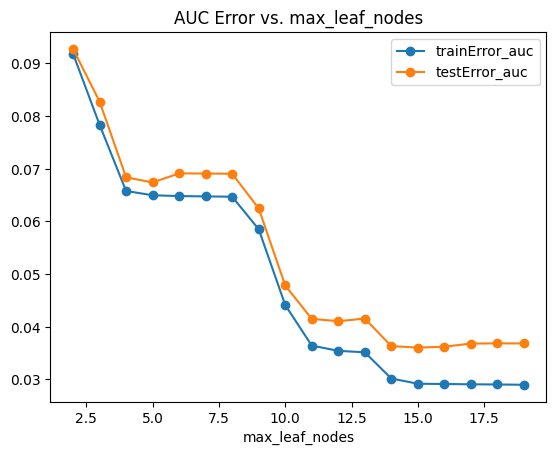

In [37]:
dfError.plot(x='max_leaf_nodes', 
             y=['trainError_auc','testError_auc'], 
             style='o-',
             title="AUC Error vs. max_leaf_nodes")

<Axes: title={'center': 'Precision and Recall Errors vs. max_leaf_nodes'}, xlabel='max_leaf_nodes'>

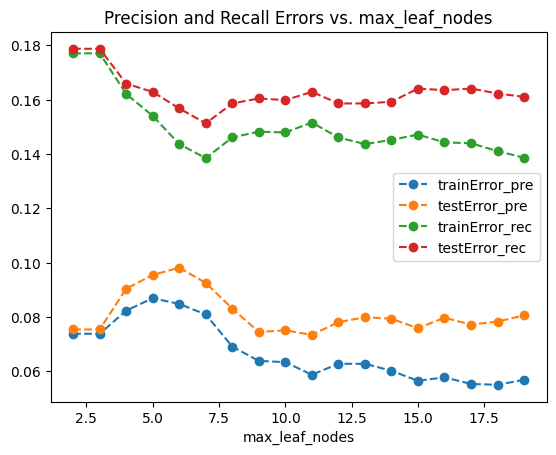

In [38]:
dfError.plot(x='max_leaf_nodes', 
             y=['trainError_pre','testError_pre',
                'trainError_rec','testError_rec'], 
             style='o--',
             title="Precision and Recall Errors vs. max_leaf_nodes")